Dataset shape: (581012, 54)
Target shape: (581012,)

Classes: [0 1 2 3 4 5 6]

Class Distribution:
Class 0: 211840
Class 1: 283301
Class 2: 35754
Class 3: 2747
Class 4: 9493
Class 5: 17367
Class 6: 20510

Imbalance Ratio: 103.13105205678923


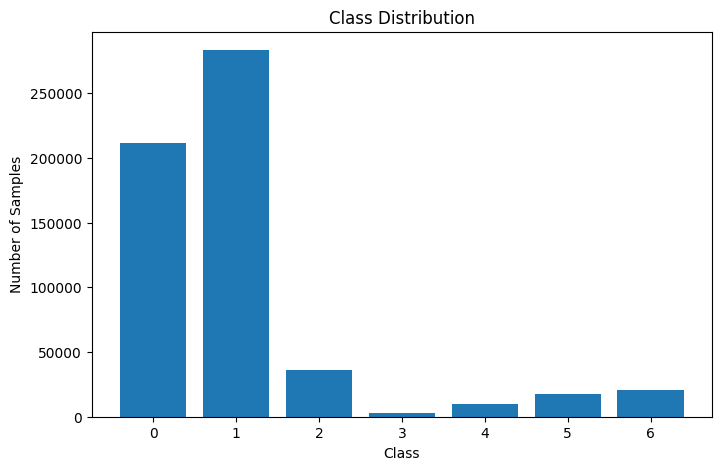


One-hot encoded shape: (581012, 7)

Data Split:
Training: (464809, 54)
Validation: (58101, 54)
Testing: (58102, 54)

Class Weights:
Class 0: 0.3918
Class 1: 0.2930
Class 2: 2.3215
Class 3: 30.2099
Class 4: 8.7439
Class 5: 4.7791
Class 6: 4.0469

Training started...
Epoch 01/50 | Train Loss: 0.6914 | Val Loss: 0.6997 | Train Acc: 0.5829 | Val Acc: 0.5828
Epoch 02/50 | Train Loss: 0.6252 | Val Loss: 0.6291 | Train Acc: 0.6162 | Val Acc: 0.6173
Epoch 03/50 | Train Loss: 0.5844 | Val Loss: 0.5923 | Train Acc: 0.6375 | Val Acc: 0.6383
Epoch 04/50 | Train Loss: 0.5763 | Val Loss: 0.5884 | Train Acc: 0.6821 | Val Acc: 0.6836
Epoch 05/50 | Train Loss: 0.5458 | Val Loss: 0.5588 | Train Acc: 0.6655 | Val Acc: 0.6645
Epoch 06/50 | Train Loss: 0.5251 | Val Loss: 0.5324 | Train Acc: 0.6753 | Val Acc: 0.6763
Epoch 07/50 | Train Loss: 0.5315 | Val Loss: 0.5432 | Train Acc: 0.6769 | Val Acc: 0.6781
Epoch 08/50 | Train Loss: 0.5097 | Val Loss: 0.5204 | Train Acc: 0.6666 | Val Acc: 0.6669
Epoch 09/50 |

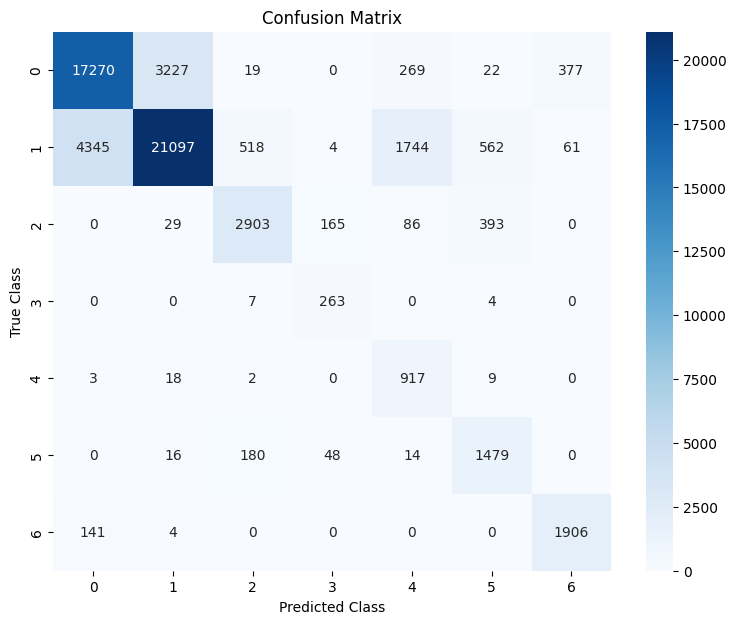

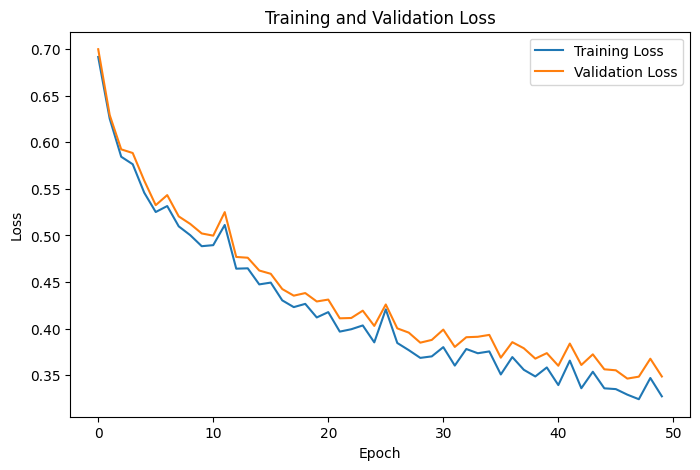

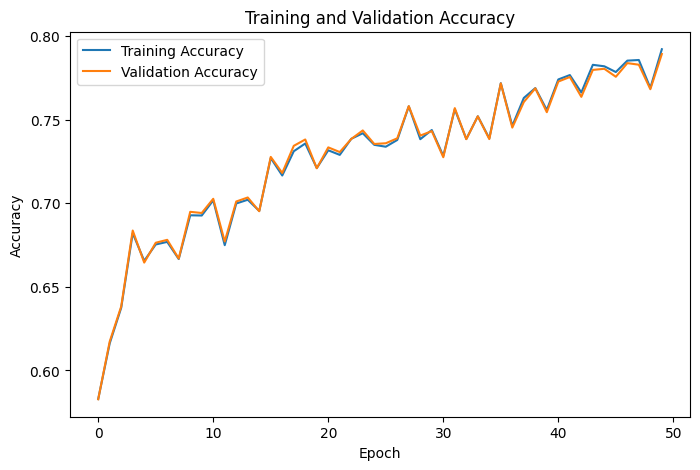

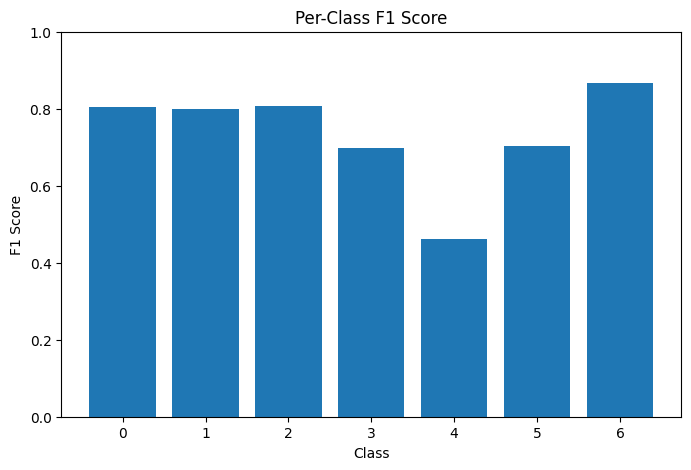

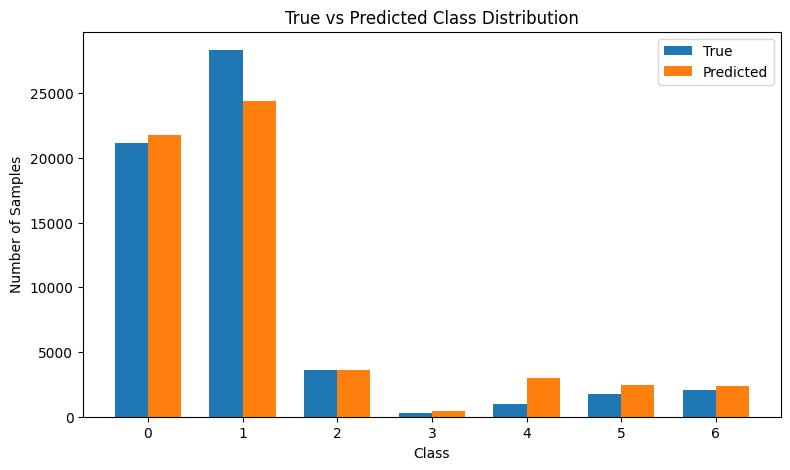

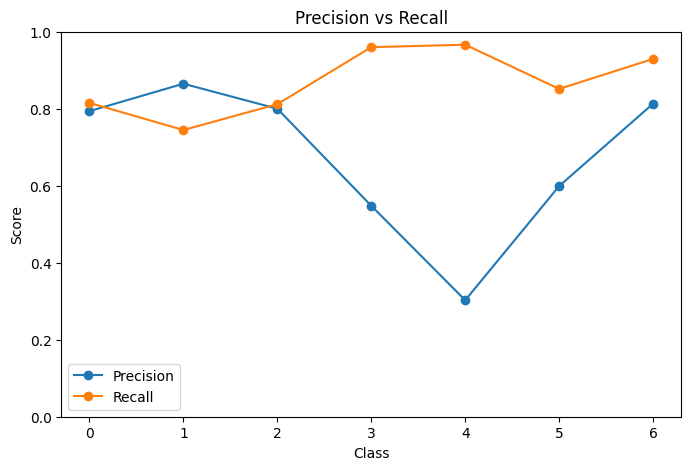


MODEL COMPLETED


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

np.random.seed(42)

data = fetch_covtype()

X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

y = y - 1

print("\nClasses:", np.unique(y))

classes, counts = np.unique(y, return_counts=True)

print("\nClass Distribution:")
for c, count in zip(classes, counts):
    print(f"Class {c}: {count}")

imbalance_ratio = counts.max() / counts.min()

print("\nImbalance Ratio:", imbalance_ratio)

plt.figure(figsize=(8, 5))
plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.show()

num_classes = 7

Y = np.zeros((len(y), num_classes))
Y[np.arange(len(y)), y] = 1

print("\nOne-hot encoded shape:", Y.shape)

X_train, X_temp, Y_train, Y_temp, y_train, y_temp = train_test_split(
    X,
    Y,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, Y_val, Y_test, y_val, y_test = train_test_split(
    X_temp,
    Y_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nData Split:")
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

N = len(y_train)
K = num_classes

class_counts = np.bincount(y_train)
class_weights = N / (K * class_counts)

print("\nClass Weights:")

for c in range(K):
    print(f"Class {c}: {class_weights[c]:.4f}")

input_size = 54
hidden1 = 64
hidden2 = 32
hidden3 = 16
output_size = 7

W1 = np.random.randn(input_size, hidden1) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden1))

W2 = np.random.randn(hidden1, hidden2) * np.sqrt(2 / hidden1)
b2 = np.zeros((1, hidden2))

W3 = np.random.randn(hidden2, hidden3) * np.sqrt(2 / hidden2)
b3 = np.zeros((1, hidden3))

W4 = np.random.randn(hidden3, output_size) * np.sqrt(2 / hidden3)
b4 = np.zeros((1, output_size))


def relu(Z):
    return np.maximum(0, Z)


def relu_derivative(Z):
    return (Z > 0).astype(float)


def softmax(Z):
    Z = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)


def forward(X):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = relu(Z3)

    Z4 = A3 @ W4 + b4
    Y_hat = softmax(Z4)

    cache = (
        X,
        Z1, A1,
        Z2, A2,
        Z3, A3,
        Z4, Y_hat
    )

    return Y_hat, cache


def compute_loss(Y, Y_hat):
    true_classes = np.argmax(Y, axis=1)
    weights = class_weights[true_classes]

    Y_hat = np.clip(Y_hat, 1e-12, 1 - 1e-12)

    sample_loss = -np.sum(
        Y * np.log(Y_hat),
        axis=1
    )

    weighted_loss = weights * sample_loss

    return np.mean(weighted_loss)


def backward(Y, Y_hat, cache):
    global W1, b1, W2, b2, W3, b3, W4, b4

    (
        X,
        Z1, A1,
        Z2, A2,
        Z3, A3,
        Z4, A4
    ) = cache

    batch_size = X.shape[0]

    true_classes = np.argmax(Y, axis=1)
    weights = class_weights[true_classes]

    dZ4 = (A4 - Y) * weights.reshape(-1, 1)
    dZ4 = dZ4 / batch_size

    dW4 = A3.T @ dZ4
    db4 = np.sum(dZ4, axis=0, keepdims=True)

    dA3 = dZ4 @ W4.T
    dZ3 = dA3 * relu_derivative(Z3)

    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)

    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return (
        dW1, db1,
        dW2, db2,
        dW3, db3,
        dW4, db4
    )


def update_parameters(gradients, learning_rate):
    global W1, b1, W2, b2, W3, b3, W4, b4

    (
        dW1, db1,
        dW2, db2,
        dW3, db3,
        dW4, db4
    ) = gradients

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

    W4 -= learning_rate * dW4
    b4 -= learning_rate * db4


def predict(X):
    Y_hat, _ = forward(X)
    return np.argmax(Y_hat, axis=1)


epochs = 50
batch_size = 128
learning_rate = 0.01
patience = 15

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

print("\nTraining started...")

for epoch in range(epochs):

    indices = np.random.permutation(len(X_train))

    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    for start in range(0, len(X_train), batch_size):

        end = start + batch_size

        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]

        Y_hat_batch, cache = forward(X_batch)

        gradients = backward(
            Y_batch,
            Y_hat_batch,
            cache
        )

        update_parameters(
            gradients,
            learning_rate
        )

    train_pred_prob, _ = forward(X_train)

    train_loss = compute_loss(
        Y_train,
        train_pred_prob
    )

    train_pred = np.argmax(
        train_pred_prob,
        axis=1
    )

    train_acc = accuracy_score(
        y_train,
        train_pred
    )

    val_pred_prob, _ = forward(X_val)

    val_loss = compute_loss(
        Y_val,
        val_pred_prob
    )

    val_pred = np.argmax(
        val_pred_prob,
        axis=1
    )

    val_acc = accuracy_score(
        y_val,
        val_pred
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1

        if patience_counter >= patience:
            print("\nEarly stopping triggered.")
            break


test_prob, _ = forward(X_test)

test_pred = np.argmax(
    test_prob,
    axis=1
)

accuracy = accuracy_score(
    y_test,
    test_pred
)

print("\n==============================")
print("TEST RESULTS")
print("==============================")

print(f"Test Accuracy: {accuracy:.4f}")

precision_per_class = precision_score(
    y_test,
    test_pred,
    average=None,
    zero_division=0
)

macro_precision = precision_score(
    y_test,
    test_pred,
    average="macro",
    zero_division=0
)

recall_per_class = recall_score(
    y_test,
    test_pred,
    average=None,
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    test_pred,
    average="macro",
    zero_division=0
)

f1_per_class = f1_score(
    y_test,
    test_pred,
    average=None,
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    test_pred,
    average="macro",
    zero_division=0
)

print("\nMacro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1 Score:", macro_f1)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        test_pred,
        zero_division=0
    )
)

cm = confusion_matrix(
    y_test,
    test_pred
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

plt.figure(figsize=(8, 5))

plt.bar(
    range(7),
    f1_per_class
)

plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Score")

plt.xticks(range(7))
plt.ylim(0, 1)

plt.show()

true_counts = np.bincount(
    y_test,
    minlength=7
)

pred_counts = np.bincount(
    test_pred,
    minlength=7
)

x = np.arange(7)
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    true_counts,
    width,
    label="True"
)

plt.bar(
    x + width / 2,
    pred_counts,
    width,
    label="Predicted"
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("True vs Predicted Class Distribution")

plt.xticks(x)
plt.legend()

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    range(7),
    precision_per_class,
    marker="o",
    label="Precision"
)

plt.plot(
    range(7),
    recall_per_class,
    marker="o",
    label="Recall"
)

plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Precision vs Recall")

plt.xticks(range(7))
plt.ylim(0, 1)

plt.legend()

plt.show()

print("\n==============================")
print("MODEL COMPLETED")
print("==============================")